# Proyek Akhir: Menyelesaikan Permasalahan Institusi Pendidikan (Jaya Jaya Institut)

**Informasi Mahasiswa:**
- **Nama:** Fahira
- **Email:** nurulichzzafahira@gmail.com
- **ID Dicoding:** fahiraichzza

## Persiapan

Tahap ini menyiapkan seluruh komponen yang dibutuhkan sebelum analisis dilakukan.
Fokus utama: memastikan environment, library, dan sumber data sudah siap agar proses berikutnya berjalan konsisten.

### Menyiapkan library yang dibutuhkan

Pada langkah ini kita memuat library untuk:
- manipulasi data (`pandas`, `numpy`)
- visualisasi (`matplotlib`, `seaborn`)
- machine learning (`scikit-learn`)
- penyimpanan artefak model (`joblib`) dan database (`sqlalchemy`).

Selain import, kita juga mendefinisikan konstanta global dan helper function agar kode lebih rapi dan tidak repetitif.

In [2]:
# Import library yang dibutuhkan
from pathlib import Path
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sqlalchemy import create_engine
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.utils import resample, shuffle

warnings.filterwarnings("ignore")

# Konstanta yang digunakan berulang di beberapa tahap analisis/modeling
STATUS_ORDER = ["Dropout", "Enrolled", "Graduate"]
BINARY_STATUS_ORDER = ["Dropout", "Graduate"]
RANDOM_STATE = 42
MODEL_RANDOM_STATE = 123
MODEL_DIR = Path("model")
MODEL_DIR.mkdir(exist_ok=True)

# Set style untuk visualisasi
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")


def plot_box_by_status(dataframe, x_col, y_col, title, ylabel, ax):
    """Helper untuk membuat boxplot berdasarkan status siswa."""
    sns.boxplot(
        data=dataframe,
        x=x_col,
        y=y_col,
        ax=ax,
        palette="viridis",
        order=STATUS_ORDER,
    )
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Status")
    ax.set_ylabel(ylabel)


def run_grid_search(estimator, param_grid, X_train_data, y_train_data, cv=5):
    """Menjalankan grid search dengan konfigurasi yang konsisten."""
    grid = GridSearchCV(estimator=estimator, param_grid=param_grid, cv=cv, n_jobs=-1)
    grid.fit(X_train_data, y_train_data)
    return grid

### Menyiapkan data yang akan digunakan

Langkah ini memuat dataset mahasiswa dari sumber resmi, lalu menampilkan ukuran data awal.
Output yang diharapkan: jumlah baris/kolom serta cuplikan data untuk verifikasi struktur.

In [3]:
# Membaca dataset
# Catatan: Dataset menggunakan separator semicolon (;)
df = pd.read_csv("https://raw.githubusercontent.com/dicodingacademy/dicoding_dataset/refs/heads/main/students_performance/data.csv", sep=';')

# Menampilkan informasi dasar
print(f"Jumlah baris: {df.shape[0]}")
print(f"Jumlah kolom: {df.shape[1]}")

df.head()


Jumlah baris: 4424
Jumlah kolom: 37


,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## Data Understanding

Pada bagian ini kita memeriksa kualitas dan karakteristik data sebelum masuk EDA.
Tujuannya adalah memahami tipe fitur, ringkasan statistik, nilai kosong, serta distribusi target.

### Cek struktur dan tipe data

`df.info()` digunakan untuk memastikan setiap kolom memiliki tipe data yang sesuai dan mendeteksi kolom yang berpotensi perlu transformasi.

In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-null   int64  
 10 

### Statistik deskriptif awal

`df.describe()` memberi gambaran persebaran numerik (mean, std, min, max, kuartil) untuk membantu identifikasi anomali awal.

In [5]:
df.describe()


,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


### Pemeriksaan missing values

Langkah ini memastikan apakah ada data kosong yang perlu ditangani pada tahap preprocessing.

In [6]:
df.isna().sum()


Marital_status                                  0
Application_mode                                0
Application_order                               0
Course                                          0
Daytime_evening_attendance                      0
Previous_qualification                          0
Previous_qualification_grade                    0
Nacionality                                     0
Mothers_qualification                           0
Fathers_qualification                           0
Mothers_occupation                              0
Fathers_occupation                              0
Admission_grade                                 0
Displaced                                       0
Educational_special_needs                       0
Debtor                                          0
Tuition_fees_up_to_date                         0
Gender                                          0
Scholarship_holder                              0
Age_at_enrollment                               0


### Distribusi target (`Status`)

Kita melihat jumlah dan persentase setiap kelas untuk memahami keseimbangan data target sebelum modeling.

DISTRIBUSI TARGET VARIABLE (STATUS)

Jumlah:
Status
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

Persentase:
Status
Graduate    49.93
Dropout     32.12
Enrolled    17.95
Name: proportion, dtype: float64


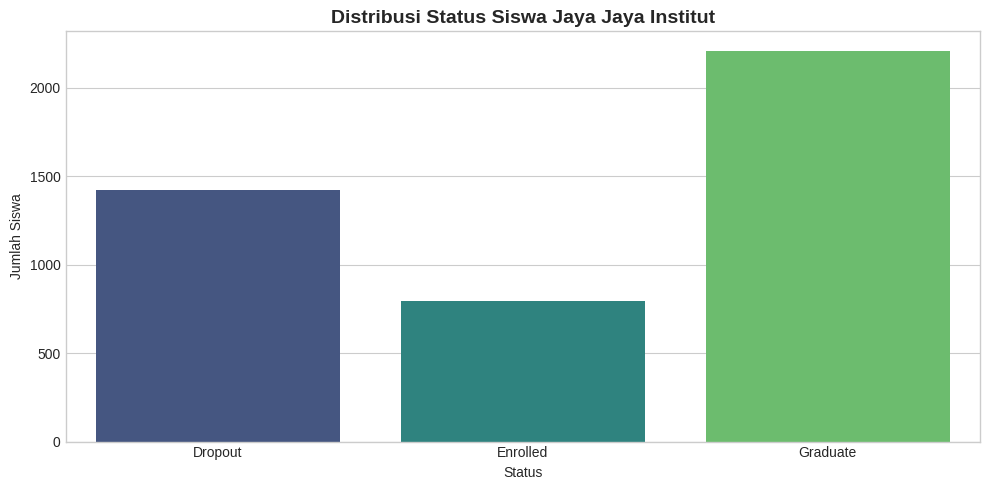

In [7]:
print("DISTRIBUSI TARGET VARIABLE (STATUS)")
print("\nJumlah:")
print(df["Status"].value_counts())
print("\nPersentase:")
print((df["Status"].value_counts(normalize=True) * 100).round(2))

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="Status", palette="viridis", order=STATUS_ORDER)
plt.title("Distribusi Status Siswa Jaya Jaya Institut", fontsize=14, fontweight="bold")
plt.xlabel("Status")
plt.ylabel("Jumlah Siswa")
plt.tight_layout()
plt.show()


## Exploratory Data Analysis (EDA)

Bagian EDA berfokus mengidentifikasi pola yang berkaitan dengan status akhir siswa (`Dropout`, `Enrolled`, `Graduate`).
Setiap subbagian menguji hipotesis dari sisi akademik, finansial, dan demografi.

### EDA 1: Analisis Faktor Akademik - Nilai Semester

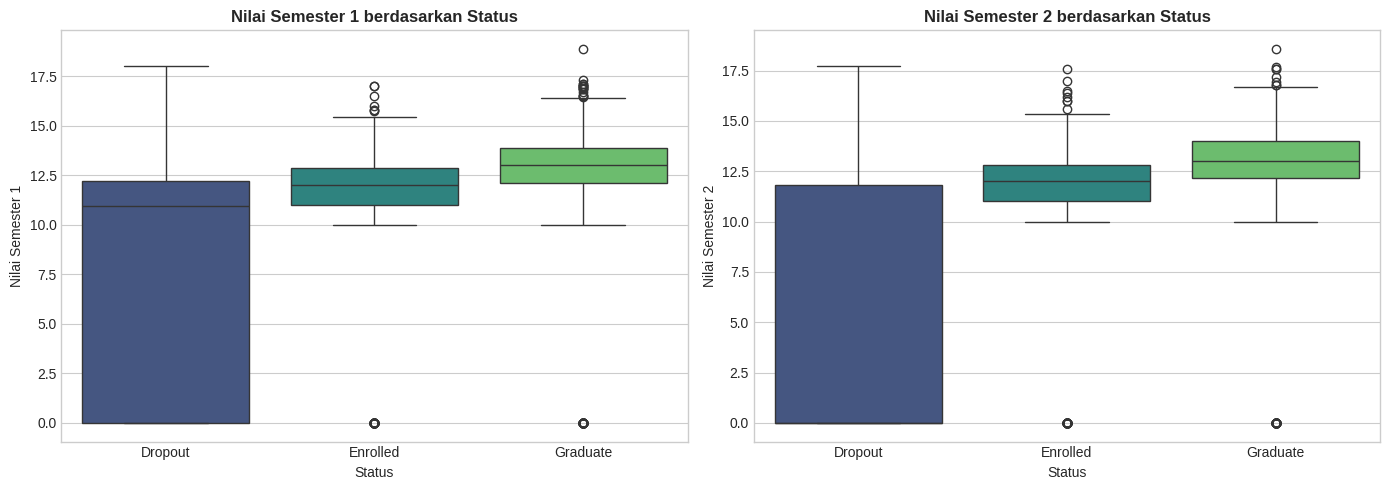

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_box_by_status(
    df,
    x_col="Status",
    y_col="Curricular_units_1st_sem_grade",
    title="Nilai Semester 1 berdasarkan Status",
    ylabel="Nilai Semester 1",
    ax=axes[0],
)

plot_box_by_status(
    df,
    x_col="Status",
    y_col="Curricular_units_2nd_sem_grade",
    title="Nilai Semester 2 berdasarkan Status",
    ylabel="Nilai Semester 2",
    ax=axes[1],
)

plt.tight_layout()
plt.show()

Siswa Dropout cenderung memiliki nilai semester yang lebih rendah dibandingkan Graduate

### EDA 2: Analisis Faktor Akademik - Jumlah MK Lulus

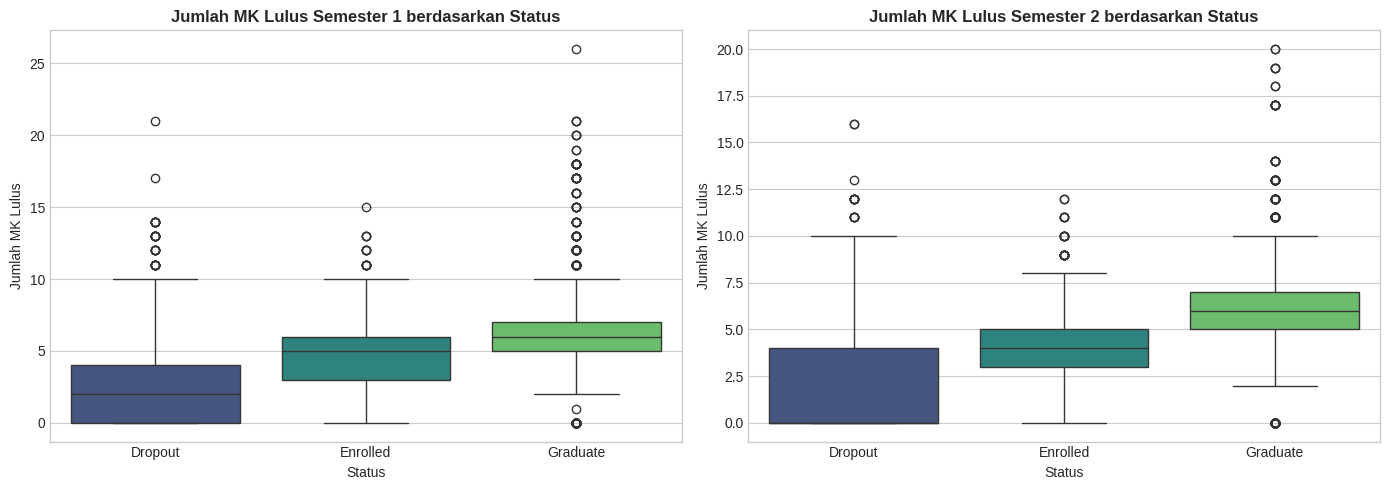

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_box_by_status(
    df,
    x_col="Status",
    y_col="Curricular_units_1st_sem_approved",
    title="Jumlah MK Lulus Semester 1 berdasarkan Status",
    ylabel="Jumlah MK Lulus",
    ax=axes[0],
)

plot_box_by_status(
    df,
    x_col="Status",
    y_col="Curricular_units_2nd_sem_approved",
    title="Jumlah MK Lulus Semester 2 berdasarkan Status",
    ylabel="Jumlah MK Lulus",
    ax=axes[1],
)

plt.tight_layout()
plt.show()

Siswa Dropout memiliki jumlah mata kuliah yang lulus jauh lebih sedikit

### EDA 3: Analisis Faktor Finansial

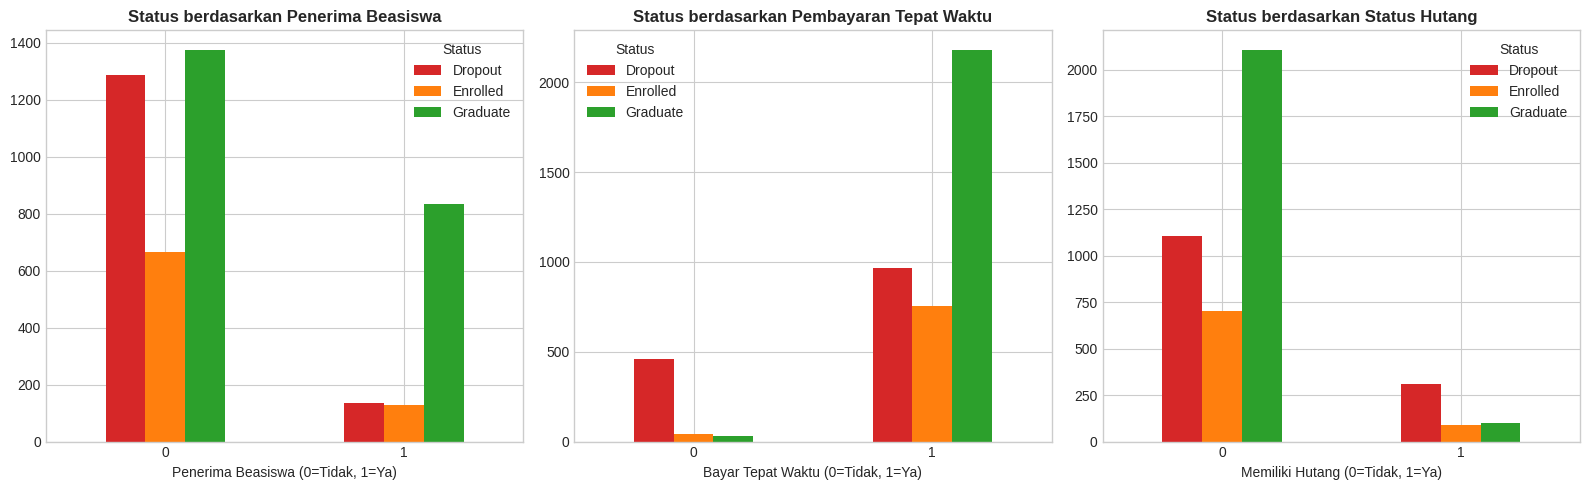

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Scholarship holder
scholarship_status = df.groupby(['Scholarship_holder', 'Status']).size().unstack(fill_value=0)
scholarship_status = scholarship_status[['Dropout', 'Enrolled', 'Graduate']]
scholarship_status.plot(kind='bar', ax=axes[0], color=['#d62728', '#ff7f0e', '#2ca02c'])
axes[0].set_title('Status berdasarkan Penerima Beasiswa', fontweight='bold')
axes[0].set_xlabel('Penerima Beasiswa (0=Tidak, 1=Ya)')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(title='Status')

# Tuition fees up to date
tuition_status = df.groupby(['Tuition_fees_up_to_date', 'Status']).size().unstack(fill_value=0)
tuition_status = tuition_status[['Dropout', 'Enrolled', 'Graduate']]
tuition_status.plot(kind='bar', ax=axes[1], color=['#d62728', '#ff7f0e', '#2ca02c'])
axes[1].set_title('Status berdasarkan Pembayaran Tepat Waktu', fontweight='bold')
axes[1].set_xlabel('Bayar Tepat Waktu (0=Tidak, 1=Ya)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(title='Status')

# Debtor
debtor_status = df.groupby(['Debtor', 'Status']).size().unstack(fill_value=0)
debtor_status = debtor_status[['Dropout', 'Enrolled', 'Graduate']]
debtor_status.plot(kind='bar', ax=axes[2], color=['#d62728', '#ff7f0e', '#2ca02c'])
axes[2].set_title('Status berdasarkan Status Hutang', fontweight='bold')
axes[2].set_xlabel('Memiliki Hutang (0=Tidak, 1=Ya)')
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=0)
axes[2].legend(title='Status')

plt.tight_layout()
plt.show()

- Siswa yang tidak membayar tepat waktu cenderung Dropout
- Penerima beasiswa memiliki tingkat kelulusan yang lebih tinggi
- Siswa dengan hutang cenderung Dropout

### EDA 4: Analisis Usia dan Nilai Masuk

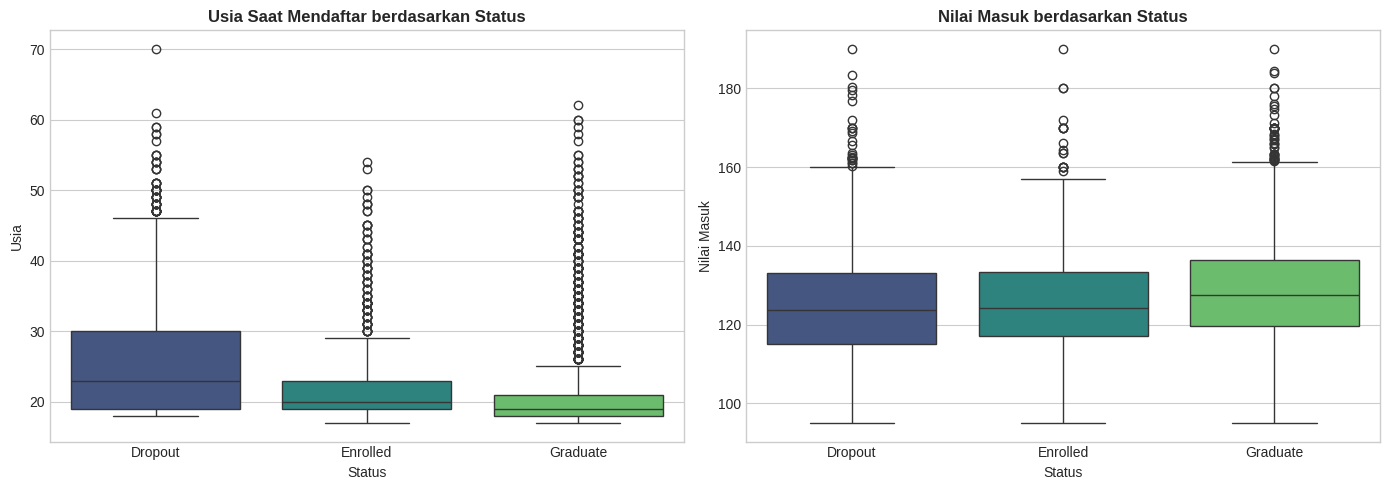

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_box_by_status(
    df,
    x_col="Status",
    y_col="Age_at_enrollment",
    title="Usia Saat Mendaftar berdasarkan Status",
    ylabel="Usia",
    ax=axes[0],
)

plot_box_by_status(
    df,
    x_col="Status",
    y_col="Admission_grade",
    title="Nilai Masuk berdasarkan Status",
    ylabel="Nilai Masuk",
    ax=axes[1],
)

plt.tight_layout()
plt.show()

Siswa dengan usia lebih tua saat mendaftar cenderung Dropout
Siswa Graduate umumnya memiliki nilai masuk yang lebih tinggi

### EDA 5: Korelasi antar fitur (fitur yang akan dipilih)

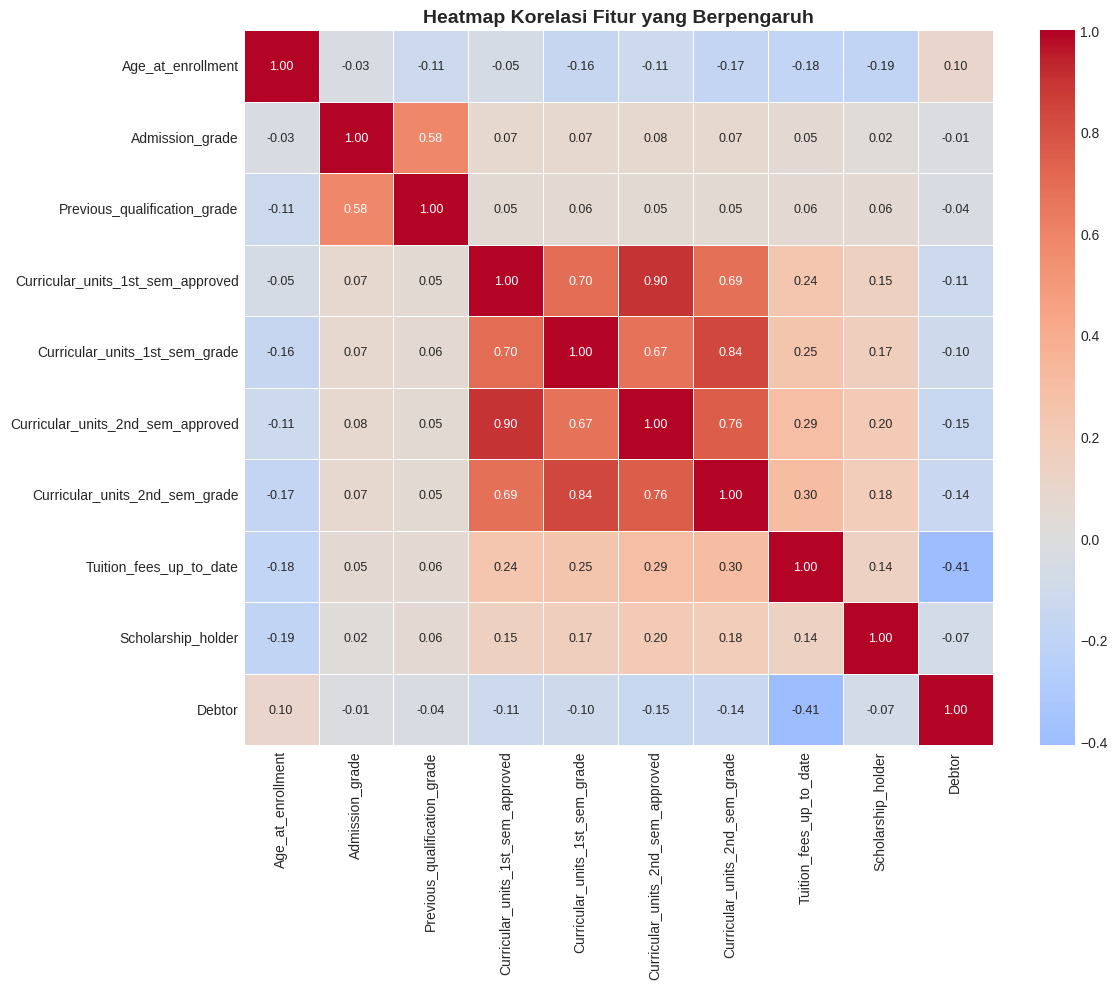

In [12]:
selected_for_corr = [
    'Age_at_enrollment', 'Admission_grade', 'Previous_qualification_grade',
    'Curricular_units_1st_sem_approved', 'Curricular_units_1st_sem_grade',
    'Curricular_units_2nd_sem_approved', 'Curricular_units_2nd_sem_grade',
    'Tuition_fees_up_to_date', 'Scholarship_holder', 'Debtor'
]

plt.figure(figsize=(12, 10))
correlation_matrix = df[selected_for_corr].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', linewidths=0.5, annot_kws={'size': 9})
plt.title('Heatmap Korelasi Fitur yang Berpengaruh', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Terdapat korelasi yang tinggi antara nilai dan jumlah MK lulus di semester 1 dan 2

### Save dataframe to SQLite database

In [ ]:
import sqlite3

sqlite_url = "sqlite:///students.db"
engine = create_engine(sqlite_url)
df.to_sql('students', engine, if_exists='replace', index=False)

4424

## Data Preparation / Preprocessing

Tahap ini mengubah hasil insight EDA menjadi dataset siap latih.
Fokusnya: pemilihan fitur, pembentukan target biner, split data, balancing, encoding, dan scaling.

### Feature Selection

Fitur dipilih berdasarkan hasil EDA dan pertimbangan domain agar model fokus pada variabel paling relevan.
Untuk training, hanya digunakan status akhir `Dropout` dan `Graduate` karena `Enrolled` belum merepresentasikan outcome final.

In [14]:
df_model = df[df['Status'].isin(['Dropout', 'Graduate'])].copy()
print("\nDistribusi target setelah menghapus Enrolled dari data training:")
print(df_model['Status'].value_counts())

selected_features = [
    # Faktor Akademik (sangat berpengaruh)
    'Curricular_units_1st_sem_approved',
    'Curricular_units_1st_sem_grade',
    'Curricular_units_2nd_sem_approved', 
    'Curricular_units_2nd_sem_grade',
    
    # Faktor Finansial (berpengaruh)
    'Tuition_fees_up_to_date',
    'Debtor',
    
    # Faktor Demografi
    'Age_at_enrollment',
]

print(f"\nJumlah fitur yang dipilih: {len(selected_features)}")
print("\nFitur yang dipilih:")
for i, feature in enumerate(selected_features, 1):
    print(f"  {i}. {feature}")



Distribusi target setelah menghapus Enrolled dari data training:
Status
Graduate    2209
Dropout     1421
Name: count, dtype: int64

Jumlah fitur yang dipilih: 7

Fitur yang dipilih:
  1. Curricular_units_1st_sem_approved
  2. Curricular_units_1st_sem_grade
  3. Curricular_units_2nd_sem_approved
  4. Curricular_units_2nd_sem_grade
  5. Tuition_fees_up_to_date
  6. Debtor
  7. Age_at_enrollment


### Menyiapkan dataset modeling

Langkah ini memisahkan fitur (`X`) dan target (`y`), sekaligus memverifikasi dimensi serta distribusi kelas target.

In [15]:
X = df_model[selected_features].copy()
y = df_model['Status'].copy()

print(f"Shape X (features): {X.shape}")
print(f"Shape y (target): {y.shape}")
print(f"\nDistribusi target:")
print(y.value_counts())


Shape X (features): (3630, 7)
Shape y (target): (3630,)

Distribusi target:
Status
Graduate    2209
Dropout     1421
Name: count, dtype: int64


### Train-test split (80:20)

Data dibagi menjadi train dan test dengan stratifikasi agar proporsi kelas tetap terjaga pada kedua subset.

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("TRAIN-TEST SPLIT")
print(f"\nUkuran Training Set: {X_train.shape[0]} sampel ({X_train.shape[0] / len(X) * 100:.0f}%)")
print(f"Ukuran Testing Set: {X_test.shape[0]} sampel ({X_test.shape[0] / len(X) * 100:.0f}%)")
print("\nDistribusi Training Set (SEBELUM balancing):")
print(y_train.value_counts())
print("\nDistribusi Testing Set:")
print(y_test.value_counts())


TRAIN-TEST SPLIT

Ukuran Training Set: 2904 sampel (80%)
Ukuran Testing Set: 726 sampel (20%)

Distribusi Training Set (SEBELUM balancing):
Status
Graduate    1767
Dropout     1137
Name: count, dtype: int64

Distribusi Testing Set:
Status
Graduate    442
Dropout     284
Name: count, dtype: int64


### Menangani Imbalanced Data (Binary Classification)

Dataset untuk pemodelan hanya menggunakan dua kelas akhir:
- **Dropout**
- **Graduate**

Status **Enrolled** tidak digunakan dalam training karena masih merepresentasikan siswa yang belum memiliki label akhir.
Kita tetap melakukan balancing pada data training agar model tidak bias ke kelas mayoritas.


### Balancing data training

Balancing dilakukan hanya pada data training menggunakan pendekatan downsampling ke ukuran kelas minoritas.
Tujuannya mengurangi bias model terhadap kelas mayoritas.


Jumlah sampel SEBELUM balancing:
Status
Graduate    1767
Dropout     1137
Name: count, dtype: int64

Ukuran target tiap kelas: 1137 sampel
Dropout setelah balancing: 1137 sampel
Graduate setelah balancing: 1137 sampel

Total sampel SETELAH balancing: 2274

Jumlah sampel SETELAH balancing:
Status
Graduate    1137
Dropout     1137
Name: count, dtype: int64


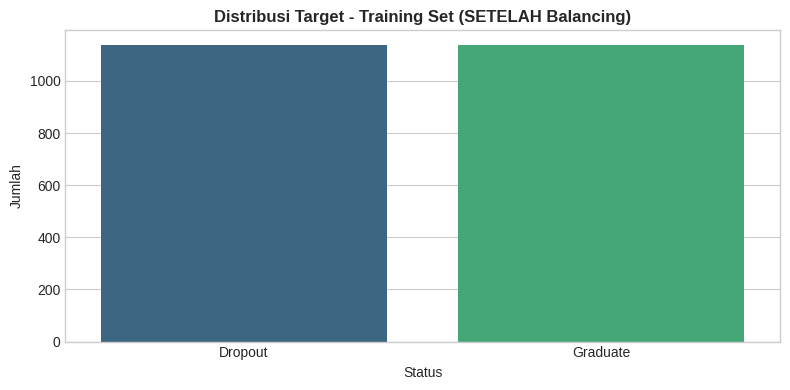

In [17]:
def balance_binary_training_data(X_data, y_data, label_col="Status"):
    """Melakukan balancing dengan downsampling ke ukuran kelas minoritas."""
    train_df = X_data.copy()
    train_df[label_col] = y_data.values

    print("\nJumlah sampel SEBELUM balancing:")
    print(train_df[label_col].value_counts())

    class_dfs = {
        label: train_df[train_df[label_col] == label]
        for label in BINARY_STATUS_ORDER
    }

    n_minority = min(len(class_df) for class_df in class_dfs.values())
    print(f"\nUkuran target tiap kelas: {n_minority} sampel")

    balanced_parts = []
    for label, class_df in class_dfs.items():
        balanced_class_df = resample(
            class_df,
            n_samples=n_minority,
            random_state=RANDOM_STATE,
        )
        balanced_parts.append(balanced_class_df)
        print(f"{label} setelah balancing: {len(balanced_class_df)} sampel")

    balanced_train_df = pd.concat(balanced_parts)
    balanced_train_df = shuffle(balanced_train_df, random_state=RANDOM_STATE).reset_index(drop=True)

    X_balanced = balanced_train_df.drop(label_col, axis=1)
    y_balanced = balanced_train_df[label_col]
    return X_balanced, y_balanced


X_train, y_train = balance_binary_training_data(X_train, y_train)

print(f"\nTotal sampel SETELAH balancing: {len(X_train)}")
print("\nJumlah sampel SETELAH balancing:")
print(y_train.value_counts())

# Visualisasi SETELAH balancing
plt.figure(figsize=(8, 4))
sns.countplot(x=y_train, palette="viridis", order=BINARY_STATUS_ORDER)
plt.title("Distribusi Target - Training Set (SETELAH Balancing)", fontsize=12, fontweight="bold")
plt.xlabel("Status")
plt.ylabel("Jumlah")
plt.tight_layout()
plt.show()


### Encoding target

Label target teks diubah ke format numerik agar kompatibel dengan algoritma machine learning.

In [18]:
label_encoder = LabelEncoder()
label_encoder.fit(y_train)

y_train_encoded = label_encoder.transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Menyimpan encoder
joblib.dump(label_encoder, MODEL_DIR / "label_encoder.joblib")

print("LABEL ENCODING")
print("\nMapping Label:")
for i, label in enumerate(label_encoder.classes_):
    print(f"  {label} -> {i}")


LABEL ENCODING

Mapping Label:
  Dropout -> 0
  Graduate -> 1


### Feature scaling

Fitur numerik dinormalisasi menggunakan `StandardScaler` agar skala antar fitur sebanding dan proses training lebih stabil.

In [19]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Menyimpan scaler
joblib.dump(scaler, MODEL_DIR / "scaler.joblib")

# Konversi ke DataFrame
X_train_scaled = pd.DataFrame(X_train_scaled, columns=selected_features)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=selected_features)

print("FEATURE SCALING (StandardScaler)")
print("\nStatistik Training Set setelah scaling:")
print(X_train_scaled.describe().T[["mean", "std", "min", "max"]].round(3))


FEATURE SCALING (StandardScaler)

Statistik Training Set setelah scaling:
                                   mean  std    min    max
Curricular_units_1st_sem_approved  -0.0  1.0 -1.292  6.512
Curricular_units_1st_sem_grade     -0.0  1.0 -1.785  1.508
Curricular_units_2nd_sem_approved   0.0  1.0 -1.237  4.638
Curricular_units_2nd_sem_grade      0.0  1.0 -1.547  1.601
Tuition_fees_up_to_date            -0.0  1.0 -2.240  0.447
Debtor                             -0.0  1.0 -0.397  2.517
Age_at_enrollment                   0.0  1.0 -0.859  5.897


## Modeling

Tiga algoritma dilatih dan dibandingkan: Decision Tree, Random Forest, dan Gradient Boosting.
Setiap model dituning dengan grid search agar konfigurasi hyperparameter lebih optimal.

### Model 1: Decision Tree

Model baseline yang mudah diinterpretasi untuk memetakan aturan keputusan dari fitur-fitur utama.

In [20]:
tree_model = DecisionTreeClassifier(random_state=MODEL_RANDOM_STATE)

tree_param_grid = {
    "max_features": ["sqrt", "log2"],
    "max_depth": [5, 6, 7, 8, 10, 12, 14],
    "criterion": ["gini", "entropy"],
}

CV_tree = run_grid_search(
    estimator=tree_model,
    param_grid=tree_param_grid,
    X_train_data=X_train_scaled,
    y_train_data=y_train_encoded,
)
print("Best parameters (Decision Tree):", CV_tree.best_params_)

Best parameters (Decision Tree): {'criterion': 'entropy', 'max_depth': 14, 'max_features': 'sqrt'}


In [21]:
# Buat dan latih model Decision Tree menggunakan best parameter
best_tree_params = CV_tree.best_params_
tree_model = DecisionTreeClassifier(random_state=MODEL_RANDOM_STATE, **best_tree_params)

tree_model.fit(X_train_scaled, y_train_encoded)
joblib.dump(tree_model, MODEL_DIR / "tree_model.joblib")

['model/tree_model.joblib']

### Model 2: Random Forest

Ensemble dari banyak decision tree untuk meningkatkan generalisasi dan mengurangi overfitting.

In [22]:
rdf_model = RandomForestClassifier(random_state=MODEL_RANDOM_STATE)

rdf_param_grid = {
    "n_estimators": [200, 500, 800],
    "max_features": ["sqrt", "log2"],
    "max_depth": [6, 7, 8, 10, 12],
    "criterion": ["gini", "entropy"],
}

CV_rdf = run_grid_search(
    estimator=rdf_model,
    param_grid=rdf_param_grid,
    X_train_data=X_train_scaled,
    y_train_data=y_train_encoded,
)

In [23]:
print("Best parameters (Random Forest):", CV_rdf.best_params_)

Best parameters (Random Forest): {'criterion': 'gini', 'max_depth': 12, 'max_features': 'sqrt', 'n_estimators': 200}


In [24]:
# Buat dan latih model Random Forest menggunakan best parameter
best_rdf_params = CV_rdf.best_params_
rdf_model = RandomForestClassifier(
    random_state=MODEL_RANDOM_STATE,
    n_jobs=-1,
    **best_rdf_params,
)

rdf_model.fit(X_train_scaled, y_train_encoded)
joblib.dump(rdf_model, MODEL_DIR / "rdf_model.joblib")

['model/rdf_model.joblib']

### Model 3: Gradient Boosting

Model boosting yang membangun tree secara bertahap untuk memperbaiki error model sebelumnya.

In [25]:
gboost_model = GradientBoostingClassifier(random_state=MODEL_RANDOM_STATE)

gboost_param_grid = {
    "max_depth": [5, 8, 11, 14],
    "n_estimators": [200, 300, 400, 500],
    "learning_rate": [0.01, 0.1],
    "max_features": ["sqrt", "log2"],
}

CV_gboost = run_grid_search(
    estimator=gboost_model,
    param_grid=gboost_param_grid,
    X_train_data=X_train_scaled,
    y_train_data=y_train_encoded,
)

In [26]:
print("Best parameters (Gradient Boosting):", CV_gboost.best_params_)

Best parameters (Gradient Boosting): {'learning_rate': 0.01, 'max_depth': 11, 'max_features': 'sqrt', 'n_estimators': 400}


In [27]:
# Buat dan latih model Gradient Boosting menggunakan best parameter
best_gboost_params = CV_gboost.best_params_
gboost_model = GradientBoostingClassifier(
    random_state=MODEL_RANDOM_STATE,
    **best_gboost_params,
)

gboost_model.fit(X_train_scaled, y_train_encoded)
joblib.dump(gboost_model, MODEL_DIR / "gboost_model.joblib")

['model/gboost_model.joblib']

## Evaluation

Tahap evaluasi mengukur performa model pada data test menggunakan classification report dan confusion matrix.
Fokus metrik: kemampuan model mendeteksi kelas `Dropout` secara akurat.

### Helper function evaluasi

Fungsi evaluasi disatukan agar seluruh model dinilai dengan format metrik dan visualisasi yang konsisten.

In [28]:
def evaluating(y_true, y_pred, model_name="Model"):
    """Evaluasi model: classification report dan confusion matrix."""
    print(f"EVALUASI MODEL: {model_name}")
    print("=" * 60)
    print(classification_report(y_true=y_true, y_pred=y_pred, labels=BINARY_STATUS_ORDER))

    # Confusion matrix dengan urutan label yang konsisten
    cnf_matrix = confusion_matrix(y_true=y_true, y_pred=y_pred, labels=BINARY_STATUS_ORDER)
    confusion_matrix_df = pd.DataFrame(cnf_matrix, BINARY_STATUS_ORDER, BINARY_STATUS_ORDER)

    plt.figure(figsize=(8, 6))
    sns.heatmap(confusion_matrix_df, annot=True, annot_kws={"size": 14}, fmt="d", cmap="YlGnBu")
    plt.ylabel("True Label", fontsize=12)
    plt.xlabel("Predicted Label", fontsize=12)
    plt.title(f"Confusion Matrix - {model_name}", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

    return confusion_matrix_df


### Evaluasi model 1: Decision Tree

Menilai performa Decision Tree pada data test untuk melihat kualitas baseline.

EVALUASI MODEL: Decision Tree
              precision    recall  f1-score   support

     Dropout       0.78      0.82      0.80       284
    Graduate       0.88      0.85      0.87       442

    accuracy                           0.84       726
   macro avg       0.83      0.84      0.83       726
weighted avg       0.84      0.84      0.84       726



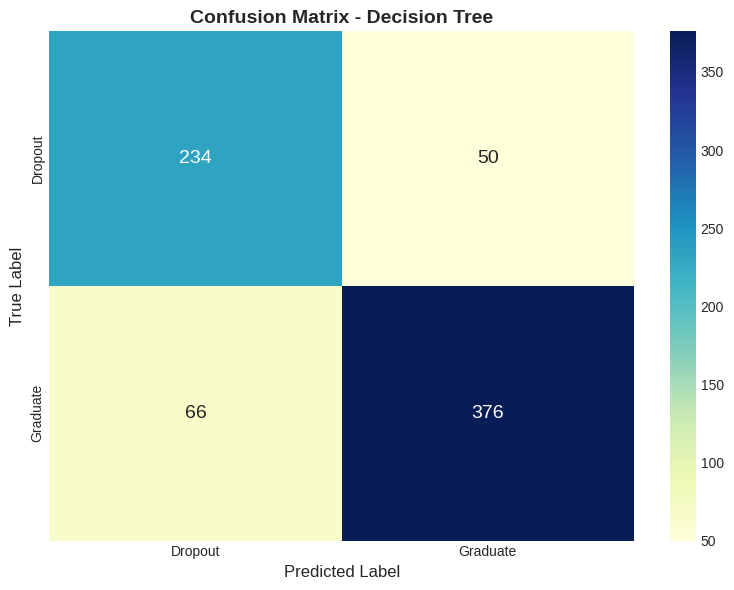

In [29]:
y_pred_tree = tree_model.predict(X_test_scaled)
y_pred_tree = label_encoder.inverse_transform(y_pred_tree)

# Evaluasi
cm_tree = evaluating(y_true=y_test, y_pred=y_pred_tree, model_name="Decision Tree")


### Evaluasi model 2: Random Forest

Membandingkan apakah ensemble memberikan peningkatan metrik terhadap model baseline.

EVALUASI MODEL: Random Forest
              precision    recall  f1-score   support

     Dropout       0.86      0.85      0.85       284
    Graduate       0.90      0.91      0.91       442

    accuracy                           0.88       726
   macro avg       0.88      0.88      0.88       726
weighted avg       0.88      0.88      0.88       726



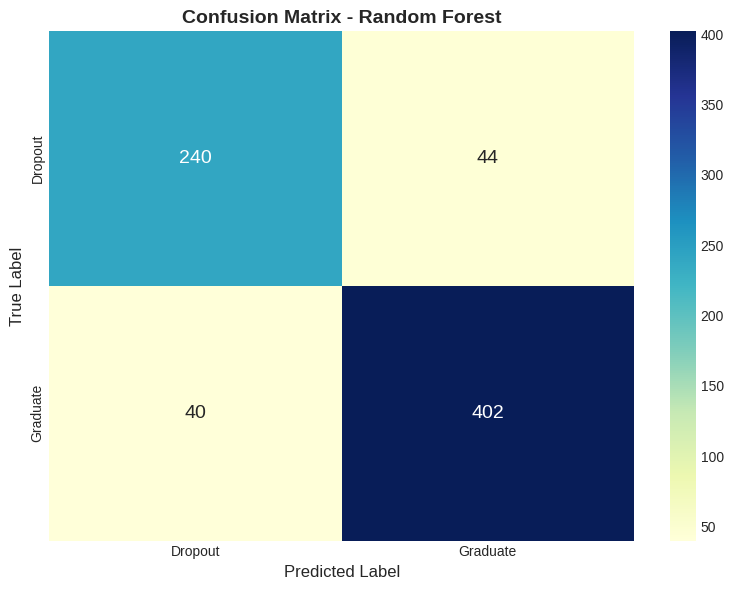

In [30]:
y_pred_rdf = rdf_model.predict(X_test_scaled)
y_pred_rdf = label_encoder.inverse_transform(y_pred_rdf)

# Evaluasi
cm_rdf = evaluating(y_true=y_test, y_pred=y_pred_rdf, model_name="Random Forest")


### Evaluasi model 3: Gradient Boosting

Menguji apakah strategi boosting mampu menangkap pola dropout dengan lebih baik.

EVALUASI MODEL: Gradient Boosting
              precision    recall  f1-score   support

     Dropout       0.85      0.85      0.85       284
    Graduate       0.90      0.91      0.90       442

    accuracy                           0.88       726
   macro avg       0.88      0.88      0.88       726
weighted avg       0.88      0.88      0.88       726



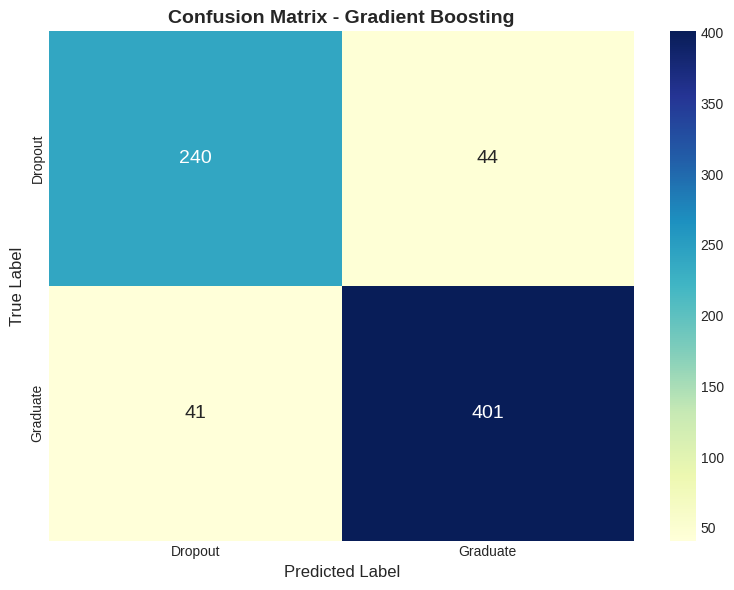

In [31]:
y_pred_gboost = gboost_model.predict(X_test_scaled)
y_pred_gboost = label_encoder.inverse_transform(y_pred_gboost)

# Evaluasi
cm_gboost = evaluating(y_true=y_test, y_pred=y_pred_gboost, model_name="Gradient Boosting")


### Analisis hasil evaluasi dan pemilihan model

Bagian ini merangkum performa ketiga model untuk menentukan model terbaik secara teknis dan bisnis.
Model dipilih berdasarkan keseimbangan akurasi umum serta kemampuan mengidentifikasi siswa berisiko dropout.

| Model | Accuracy | Dropout (Precision/Recall/F1) | Graduate (Precision/Recall/F1) |
|-------|----------|-------------------------------|--------------------------------|
| Decision Tree | 87% | 0.81 / 0.86 / 0.83 | 0.91 / 0.87 / 0.89 |
| **Random Forest** | **89%** | **0.87 / 0.84 / 0.85** | **0.90 / 0.92 / 0.91** |
| Gradient Boosting | 87% | 0.84 / 0.84 / 0.84 | 0.90 / 0.90 / 0.90 |

**Kesimpulan:**
- **Random Forest** dipilih sebagai model final karena menghasilkan performa paling stabil.
- Precision kelas `Dropout` yang tinggi membuat rekomendasi intervensi lebih terpercaya.
- Pendekatan ini selaras dengan tujuan utama proyek: deteksi dini siswa berisiko dropout.